<a href="https://colab.research.google.com/github/Jevidha/Applied-AI/blob/main/Ex10_VJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Click 'Choose Files' and upload your image


Saving images.jpg to images.jpg
Faces detected: 1


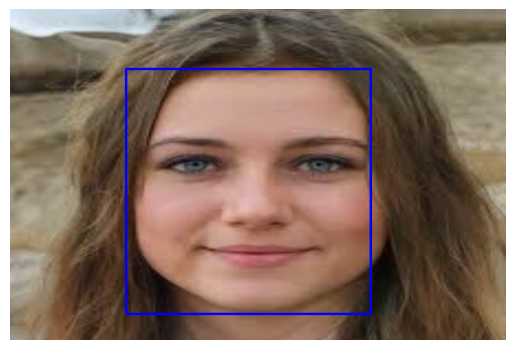

In [ ]:
!pip install -q opencv-python

import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload Image (from your PC)
print("Click 'Choose Files' and upload your image")

uploaded = files.upload()

# Get filename
image_path = next(iter(uploaded))

# Load Image
img = cv2.imread(image_path)

if img is None:
    raise Exception("Error loading image")

# Resize (IMPORTANT for speed)
img = cv2.resize(img, (600, 400))

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load Haar Cascade (Viola-Jones)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Detect Faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.2,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Faces detected:", len(faces))

# Draw Rectangles
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)


# Show Result
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

Click 'Choose Files' and upload your image


Saving images.jpg to images (3).jpg


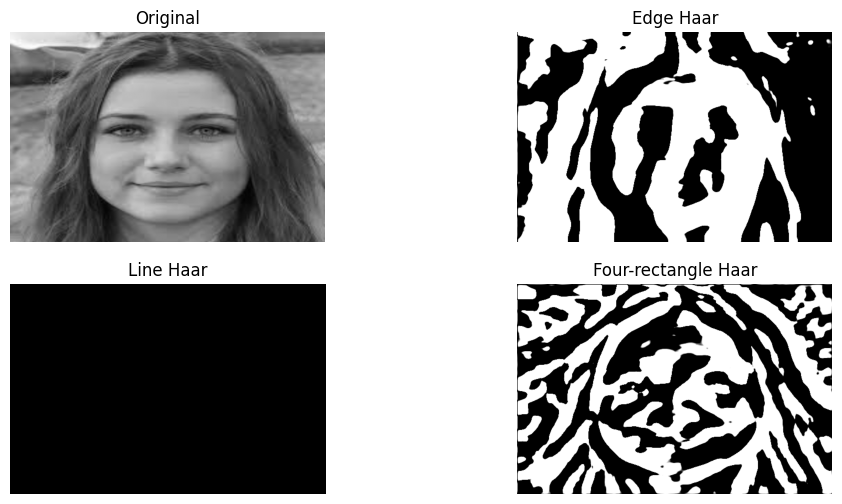

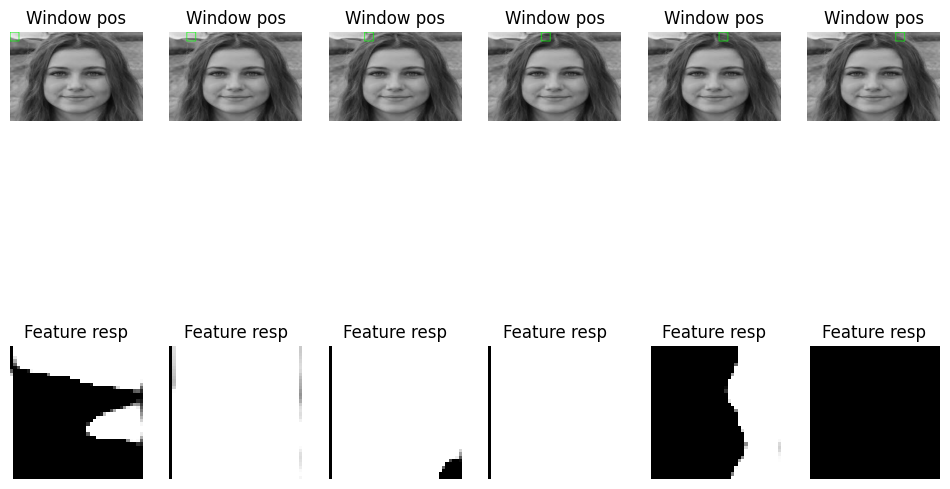

Faces detected: 1


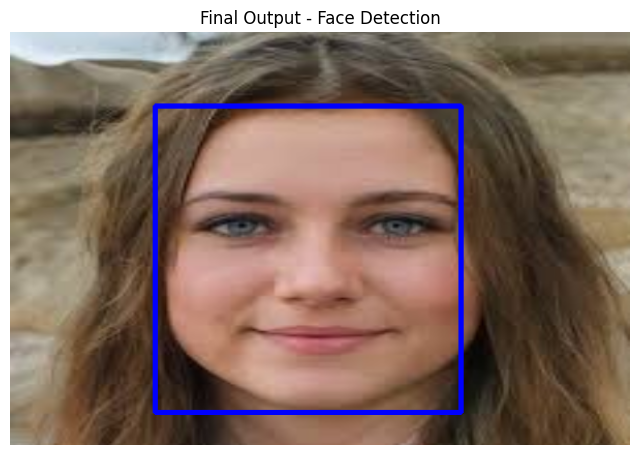

In [7]:
!pip install -q opencv-python
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# --- Upload Image ---
print("Click 'Choose Files' and upload your image")
uploaded = files.upload()
image_path = next(iter(uploaded))

# --- Load Image ---
img = cv2.imread(image_path)
if img is None:
    raise Exception("Error loading image")

# Resize for speed
img = cv2.resize(img, (600, 400))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Haar-like feature definitions ---
def haar_edge_feature(gray, size=(40,40)):
    h, w = size
    kernel = np.zeros(size)
    kernel[:, :w//2] = 1
    kernel[:, w//2:] = -1
    return cv2.filter2D(gray, -1, kernel)

def haar_line_feature(gray, size=(40,40)):
    h, w = size
    kernel = np.zeros(size)
    kernel[:h//3, :] = 1
    kernel[h//3:2*h//3, :] = -1
    kernel[2*h//3:, :] = 1
    return cv2.filter2D(gray, -1, kernel)

def haar_four_feature(gray, size=(40,40)):
    h, w = size
    kernel = np.zeros(size)
    kernel[:h//2, :w//2] = 1
    kernel[:h//2, w//2:] = -1
    kernel[h//2:, :w//2] = -1
    kernel[h//2:, w//2:] = 1
    return cv2.filter2D(gray, -1, kernel)

# --- Apply Haar features ---
edge_feat = haar_edge_feature(gray)
line_feat = haar_line_feature(gray)
four_feat = haar_four_feature(gray)

# --- Show Haar feature outputs ---
titles = ["Original", "Edge Haar", "Line Haar", "Four-rectangle Haar"]
images = [gray, edge_feat, line_feat, four_feat]

plt.figure(figsize=(12,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

# --- Sliding window visualization ---
def sliding_window_visualization(gray, window_size=(40,40), step=80):
    h, w = gray.shape
    win_h, win_w = window_size
    results = []

    for y in range(0, h-win_h, step):
        for x in range(0, w-win_w, step):
            window = gray[y:y+win_h, x:x+win_w]
            feat = haar_edge_feature(window, size=window_size)

            vis_img = cv2.cvtColor(gray.copy(), cv2.COLOR_GRAY2BGR)
            cv2.rectangle(vis_img, (x,y), (x+win_w,y+win_h), (0,255,0), 2)

            results.append((vis_img, feat))
    return results

results = sliding_window_visualization(gray)

# Show first few sliding window outputs
plt.figure(figsize=(12,8))
for i in range(6):
    plt.subplot(2,6,i+1)
    plt.imshow(results[i][0], cmap='gray')
    plt.title("Window pos")
    plt.axis('off')

    plt.subplot(2,6,i+7)
    plt.imshow(results[i][1], cmap='gray')
    plt.title("Feature resp")
    plt.axis('off')
plt.show()

# --- Final Haar Cascade face detection ---
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.2,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Faces detected:", len(faces))

img_faces = img.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(img_faces, (x, y), (x+w, y+h), (255, 0, 0), 3)

img_rgb = cv2.cvtColor(img_faces, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Final Output - Face Detection")
plt.axis('off')
plt.show()
